In [1]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# ---------------------------------------------------------------------------*/
# - prepare a dataset

# define known data properties
timeseries_len  = 111
timestep        = 0.001
dataset_dir     = 'cavity/10Hz'

# read data from files
data_train = utils.read_datafile(f'{dataset_dir}/train1', timeseries_len)
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)

# data channels are expected to contain:
# 1. displacement
# 2. velocity
# 3. derivative of displacement
# 4. derivative of velocity
# 5. rf field gradient
# 6. derivative of rf field gradient
x_dims_n = 2
u_dims_n  = 1

# compile dataset parameters
data_table = [
    ( 'dataset',           'batches',        'timeseries length',          'channels'),
    ('--------',           '-------',        '-----------------',          '--------'),
    (   'train', data_train.shape[0], data_train.shape[1], data_train.shape[2]),
    (   'valid', data_valid.shape[0], data_valid.shape[1], data_valid.shape[2]),
    (    'test',  data_test.shape[0],  data_test.shape[1],  data_test.shape[2]) ]

# print dataset parameters
print('inf >> dataset parameters:')
print('')
for row in data_table:
    print(f'{row[0]:>8} {row[1]:>8} {row[2]:>18} {row[3]:>8}')

inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                111        6
   valid     1000                111        6
    test      500                111        6


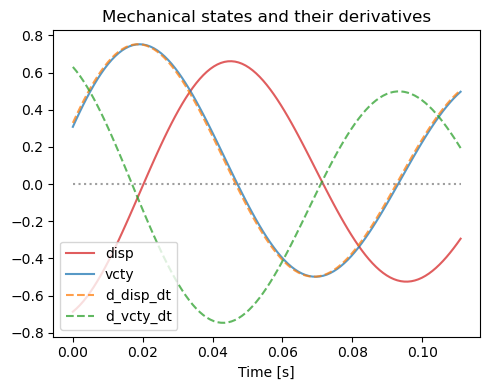

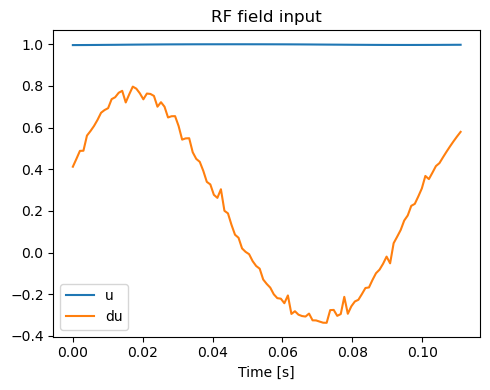

In [3]:
data_i = 444
data_viz = data_train[data_i]
t_viz = torch.linspace(0., timestep*timeseries_len, timeseries_len)
zero_viz = torch.zeros_like(t_viz)

plt.figure(figsize=(5, 4))
plt.title('Mechanical states and their derivatives')
plt.plot(t_viz, data_viz[:, 0], color='tab:red', alpha=0.75, label='disp')
plt.plot(t_viz, data_viz[:, 1], color='tab:blue', alpha=0.75, label='vcty')
plt.plot(t_viz, data_viz[:, 2], color='tab:orange', linestyle='dashed', alpha=0.75, label='d_disp_dt')
plt.plot(t_viz, data_viz[:, 3], color='tab:green', linestyle='dashed', alpha=0.75, label='d_vcty_dt')
plt.plot(t_viz, zero_viz, color='tab:gray', linestyle='dotted', alpha=0.75)
plt.legend()
plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.title('RF field input')
plt.plot(t_viz, data_viz[:, 4], label='u')
plt.plot(t_viz, data_viz[:, 5], label='du')
plt.xlabel('Time [s]')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# ---------------------------------------------------------------------------*/
# - instantiate dynamic mode decomposition

print(f'inf >> number of data dimensions is {x_dims_n}')
print(f'inf >> number of control dimensions is {u_dims_n}')

config = {
    'x_dims_n'               : x_dims_n,
    'u_dims_n'               : u_dims_n,

    'modes'                  : [(2*torch.pi*10., 0.1)],

    'timestep'               : timestep,
    'predict_horizon'        : 111,
    'batch_size'             : 256,
    'loss_wt_ae'             : 1e0,
    'loss_wt_phys_enc'       : 1e0,
    'loss_wt_phys_dec'       : 1e0,
    'loss_wt_lin'            : 1e0
}

model = care.deep_koopman(config)

inf >> number of data dimensions is 2
inf >> number of control dimensions is 1


inf >> Number of data files for training : 7
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3
inf >> Processing training file number 4
inf >> Processing training file number 5
inf >> Processing training file number 6
inf >> Processing training file number 7


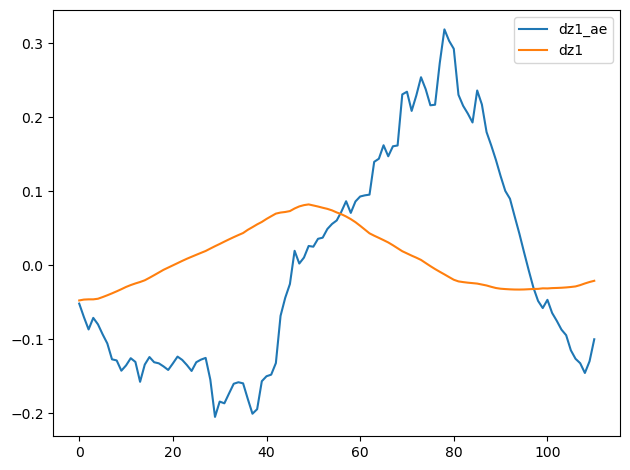

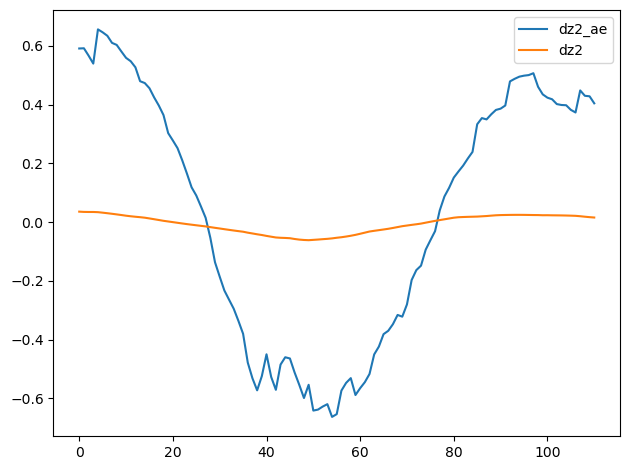

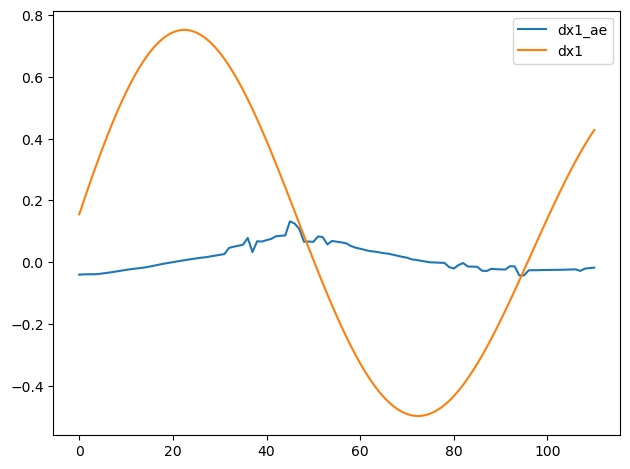

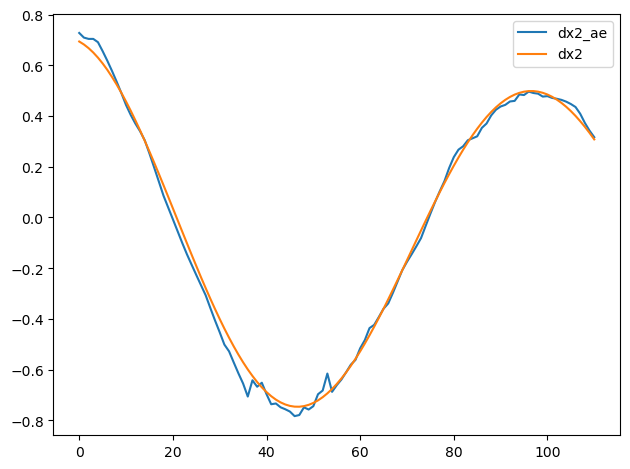

q is -0.028040938079357147
w is -0.02109721675515175
k is -0.42775416374206543


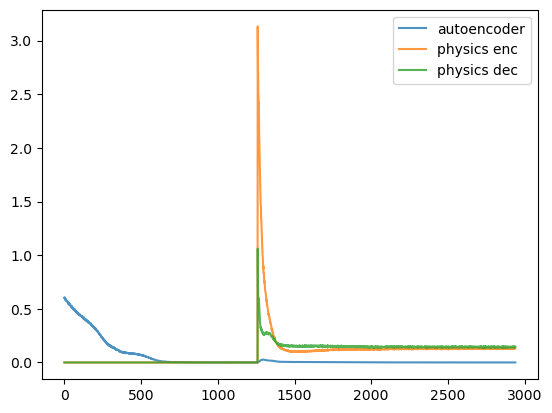

NameError: name 'tata' is not defined

In [5]:
# ---------------------------------------------------------------------------*/
# - training and validation

batch_size = config['batch_size']

# make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

# specify optimizer and a loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-9)

# specify the length of our validated prediction
prediction_steps_n = timeseries_len

loss_train_ae = []
loss_train_phys_enc = []
loss_train_phys_dec = []
err_train_lin = []
err_train_phys = []

err_valid_recon = []
err_valid_pred = []

datafiles_train_n = 7#random.randint(4, 6)
print(f"inf >> Number of data files for training : {datafiles_train_n}")

horizon_valid = config['predict_horizon']

for datafile_train in range(datafiles_train_n):
    print(f"inf >> Processing training file number {datafile_train + 1}")
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)

    # make training datasets and loaders
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    # train
    for epoch in range(30):

        # train neural networks
        for this, data in enumerate(dataloader_train):
            x  = data[0][:, :, :2]
            dx = data[0][:, :, 2:4]
            u  = data[0][:, :, -2:-1]
            du = data[0][:, :, -1:]

            # inputs x and u require a gradient to later calculate the gradient of an encoder
            x.requires_grad_()
            u.requires_grad_()

            optimizer.zero_grad()

            ae_only = datafile_train < 3

            # test ~ test ~ test
            #print(len(dataloader_train))
            # 128 -> 27
            # 64 -> 54
            # 256 -> 13
            now = this==13 and epoch==29 and datafile_train==6

            if ae_only:
                loss = model.fit_autoencoder(x, u)
                loss_ae = loss
                loss_phys_enc = 0.
                loss_phys_dec = 0.
            else:
                loss, loss_ae, loss_phys_enc, loss_phys_dec = model.fit(x, dx, u, du, now)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                loss_train_ae.append(loss_ae)
                loss_train_phys_enc.append(loss_phys_enc)
                loss_train_phys_dec.append(loss_phys_dec)

            if now:
                with torch.no_grad():
                    plt.figure()
                    plt.plot(loss_train_ae, alpha=0.8, label='autoencoder')
                    plt.plot(loss_train_phys_enc, alpha=0.8, label='physics enc')
                    plt.plot(loss_train_phys_dec, alpha=0.8, label='physics dec')
                    plt.legend()
                    plt.show()
                    print(tata.shape)

        # validate results
        #with torch.no_grad():
            #for data in dataloader_valid:
                #timeseries = data[0][:, :, :2]
                #control    = data[0][:, :, -1:]

                # validate prediction
                #timeseries_pred = model.predict(timeseries, control, horizon_valid)
                #err_valid_pred.append(torch.mean((timeseries[:, :horizon_valid, :] - timeseries_pred)**2))

                # validate reconstruction
                #timeseries_recon = model.reconstructor(model.decomposer(timeseries))
                #err_valid_recon.append(torch.mean((timeseries - timeseries_recon)**2))


In [ ]:
with torch.no_grad():
    plt.figure(figsize=(6, 3.5))
    plt.plot(err_train_lin, alpha=0.8, label='linearity')
    plt.plot(err_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(err_train_phys, alpha=0.8, label='physics')
    plt.xlabel("Training batch #")
    plt.ylabel("Error")
    #plt.ylim((0,10))
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.plot(err_valid_pred, alpha=0.8, label='prediction')
    plt.plot(err_valid_recon, alpha=0.8, label='reconstruction')
    plt.xlabel("Validation batch #")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

In [ ]:
# ---------------------------------------------------------------------------*/
# - test results : check the distribution of frequencies in eigenfunctions

with torch.no_grad():
    eigenfuncs = model.decomposer(model.start_of(data_test[:, :, :2]))
    eigenvalues = model.dynamics(eigenfuncs)

    eigenfuncs = torch.squeeze(eigenfuncs, 1)
    eigenvalues = torch.squeeze(eigenvalues, 1)

    osc_eigenfuncs_n = int(eigenfuncs.shape[1]/len(config['modes']))
    osc_eigenvalues_n = int(eigenvalues.shape[1]/len(config['modes']))

    # split eigenfunctions and eigenvalues per oscillator to facilitate their analysis and displaying
    osc_eigenfuncs = torch.split(eigenfuncs.T, osc_eigenfuncs_n, dim=0)
    osc_eigenvalues = torch.split(eigenvalues.T, osc_eigenvalues_n, dim=0)

    osc_i = range(len(config['modes']))

    for eigenfunc, eigenvalue, i in zip(osc_eigenfuncs, osc_eigenvalues, osc_i):

        eva_e_min = torch.min(eigenvalue[0, :])
        eva_e_max = torch.max(eigenvalue[0, :])
        print(f"inf >> Eigenvalue scaling ranges from {eva_e_min:.2f} to {eva_e_max:.2f}")

        eva_f_min = torch.min(eigenvalue[1, :])
        eva_f_max = torch.max(eigenvalue[1, :])
        print(f"inf >> Eigenvalue frequency ranges from {eva_f_min:.2f} to {eva_f_max:.2f}")

        plt.figure()
        plt.scatter(eigenfunc[0, :], eigenfunc[1, :], c=eigenvalue[1, :])
        plt.title(f'Frequency ranges from {eva_f_min:.2f} to {eva_f_max:.2f} rad/s')
        plt.xlabel('$z_1$')
        plt.ylabel('$z_2$')
        plt.colorbar()
        #plt.savefig(f'fig/pendulum/play_dmd_10rad_efn_ic_by_freq_{i}.svg')
        plt.show()


In [ ]:
with torch.no_grad():
    data_test_i = 444
    test_horizon = 101

    timeseries = data_test[torch.newaxis, data_test_i][:, :, :2]
    control = data_test[torch.newaxis, data_test_i][:, :, 2:]

    timeseries_pred = model.predict(timeseries, control, test_horizon)

    plt.figure(figsize=(5,5))
    plt.title(f'Predicting {test_horizon} steps of test timeseries')
    plt.plot(timeseries[0, :test_horizon, 0], timeseries[0, :test_horizon, 1], label='true')
    plt.plot(timeseries[0, 0, 0], timeseries[0, 0, 1], '--bo', label='initial condition')
    plt.plot(timeseries_pred[0, :, 0], timeseries_pred[0, :, 1], linestyle='dashed', label='predicted')
    plt.legend()
    plt.xlabel("$\\Delta\\omega$")
    plt.ylabel("$\\dot{\\Delta}\\omega$")
    plt.tight_layout()
    #plt.savefig(f'fig/cavity/train_test_{data_test_i}_k_on_80_vr_10MV_vm_10Hz.svg')
    plt.show()

In [ ]:
with torch.no_grad():
    data_test_i = 444

    efn = model.decomposer(data_test[torch.newaxis, data_test_i][:, :, :2])
    efns = torch.split(efn, model.decomposer.rad_dims_n, dim=-1)

    for i, this_efn in enumerate(efns):
        plt.figure(figsize=(5,5))
        plt.title('Exemplifying a two-dimensional latent space $z$')
        plt.plot(this_efn[0, :, 0], this_efn[0, :, 1])
        plt.plot(this_efn[0, 0, 0], this_efn[0, 0, 1], '--bo', label='initial condition')
        plt.xlabel('$z_1$')
        plt.ylabel('$z_2$')
        plt.tight_layout()
        #plt.savefig(f'fig/cavity/train_test_{data_test_i}_z_example_{i}.svg')
        plt.show()
